**Examinationsarbete i Deep Learning**

**Project $alpha$**

Målbild:

- Designa och träna Convolutional Neural Networks (CNNs) från grunden, för att klassificera bilder i CIFAR-10 datasetet.

Generella och specifika kraven för betygsgränser beskrivs längre ner.

---

**Dataset, CIFAR-10**

- **Antal bilder:** 60,000 (32x32 pixlar, färgbilder).
- **Klasser:** 10 klasser (t.ex. flygplan, bil, fågel, katt).
- **Uppdelning:**
  - Träning: 50,000 bilder.
  - Test: 10,000 bilder.

**Evalueringskrav**

Datasetet ska laddas in från PyTorchs `torchvision` bibliotek, och tillhörande testset ska användas för evaluering. 

---

**Project $alpha$**


Här ska ni designa och träna Convolutional Neural Networks (CNNs) från grunden, i syfte att klassificera bilder i CIFAR-10-datasetet. Modellerna som tränas för att uppnå kraven för **G** samt **VG** nedan får *ej* vara pretrained. 

**Krav för G:**
- Mellan **75-80% accuracy** på test-settet.
- Designa, träna och evaluera minst **tre olika CNN-arkitekturer**.
- Prestandan av varje färdigtränad modell ska vara tydlig, och även loss-kurvor ska plottas - följt av en kortfattad analys av dessa.
- I varje CNN-klass ska, i `forward`-metoden, **storleken på input och output för varje operation** skrivas ut som en kommentar.
- Gör dessutom en **kvalitativ analys** av dina modellers prestanda (vilka klasser presteras bra på, och vilka dåligt) - och varför, om möjligt.

**Krav för VG:**

- Uppnår kraven för **G**, och når **85%+ accuracy** på test-settet.
- Ni använder dessutom flertalet metoder under träningen som ni själva läst på och lärt er om, exempelvis via litteraturhänvisningen.
    - samtliga metoder, utöver de vi gått igenom i klassen, som ni väljer att använda ska ni i ett särskilt stycke i er notebook, förklara (så gott ni kan) 
    samt ge referenser till.
- Ni ska även att utföra en ordentlig error analysis, på er bäst presterade modell.

**Krav för Guldstjärna:**

- Uppnår kraven för **VG**, och når **90%+ accuracy** på test-settet.
- Hittar även en lämplig pretrained modell, anpassar den för datasetet samt uppnår **95%+** accuracy på test-settet. 





Var kreativa med era arkitekturer. Ni behöver exempelvis inte begränsa er till det 'normala' convolutional block som vi 
lärde oss under föreläsningarna (dvs conv layer + relu följt av pooling), utan det kan se annorlunda ut. Se litteraturhänvisningarna för inspiration från kända CNN-arkitekturer som ex. AlexNet, VGG, ResNet etc. 

Utöver det finns det andra knep man kan integrera in i sin CNN som empiriskt visat förbättra prestanda. Exempelvis:

- Batch Normalization
- Data Augmentation
- Alternativa Optimizers (ex Adam, RMSprop)
- Learning Rate Scheduling

Ni har friheten att själva söka information om dessa och hur de implementeras i PyTorch, för att sedan nyttja dem i ert projekt.

**Pre-trained models & Transfer Learning**

Kraven för **G** och **VG** utgår utifrån att man tränat modeller från grunden. För Guldstjärna ska ni som sagt även nyttja transfer learning med en redan färdigtränad modell. Det räcker med en sådan, om ni lyckas uppnå 95% accuracy på test-settet.

Det kan dock vara rätt beräkningstungt.

---

**Inlämning**



Ni lämnar in en notebook fil som innehåller allt arbete. Notebooken ska dessutom sparas med alla outputen kvarstående! 

Mao ska jag bara kunna bläddra igenom er notebook för att se allt arbete och alla output, utan att för den delen köra koden själv.

Spara notebook:en med namnet **{namn}\_{efternamn}\_{alpha}.ipynb**, och skicka därefter in via elevera-portalen.

---

**Literaturlista**

Följande research ger både en inblick i historiken av CNN-arkitekturers utveckling, och kan ge idéer om nyttiga idéer i era egna projekt:

* [__LeNet-5__](http://yann.lecun.com/exdb/lenet/). Grundläggande arbete som introducer konceptet med Convolutional Neural Networks.
* [__AlexNet__](https://papers.nips.cc/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf). Vann ImageNet-tävlingen 2012, genom att bland annat introducera "ReLU".
* [__VGGNet__](https://arxiv.org/abs/1409.1556).
* [__GoogLeNet__](https://arxiv.org/abs/1409.4842). Introducerade "Inception"-modulen (aka "bottle-neck layer").
* [__ResNet__](http://openaccess.thecvf.com/content_cvpr_2016/papers/He_Deep_Residual_Learning_CVPR_2016_paper.pdf). Introducerar "skip connections" som hjälper djupa nätverk att lära sig. 
* [__EfficientNet__](https://arxiv.org/abs/1905.11946)

Ni kan givetvis lära er mer om dessa koncept genom att söka efter alternativa källor också.





In [1]:
#Import libraries
import torch
from torchvision import models
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import random_split
from sklearn.metrics import confusion_matrix
import seaborn as sns

---
## **Data preparation**

In [2]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# Load CIFAR-10 dataset
train_base = datasets.CIFAR10(root='./data', train=True, download=True)
test_base = datasets.CIFAR10(root='./data', train=False, download=True)

# Split train into train and validation
indices = list(range(50000))
train_idx, val_idx = indices[:45000], indices[45000:]

# Custom dataset to apply transforms on subsets
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, indices=None, transform=None):
        self.dataset = dataset
        self.indices = indices if indices is not None else range(len(dataset))
        self.transform = transform
    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.indices)

train_data = ApplyTransform(train_base, train_idx, train_transform)
val_data = ApplyTransform(train_base, val_idx, test_transform)
test_data = ApplyTransform(test_base, None, test_transform)

# DataLoaders
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

/Users/wijdancederlid/Desktop/deep_ML/deeplearning/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


---
## **Defining training function**

In [3]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu') # Use MPS if available otherwise CPU
    model.to(device)
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            scheduler.step()
            running_train_loss += loss.item()
        
        model.eval()
        running_val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        avg_train_loss = running_train_loss / len(train_loader)
        avg_val_loss = running_val_loss / len(val_loader)
        val_acc = 100 * correct / total if total > 0 else 0

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        print(f'Epoch [{epoch+1}/{epochs}] - '
              f'Train Loss: {avg_train_loss:.4f}, '
              f'Val Loss: {avg_val_loss:.4f}, '
              f'Val Acc: {val_acc:.2f}% - '
              f'LR: {scheduler.get_last_lr()[0]:.6f}')
              
    print("Training completed!")
    return train_losses, val_losses, val_accuracies

---
## **Model nr 1**

In [4]:
# Define CNN model number 1
class CNN1(nn.Module):
    def __init__(self):
        super(CNN1, self).__init__()
        
        # Feature extraction layers
        self.features = nn.Sequential(
            #Input: [3, 32, 32]
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding='same'),  
            nn.BatchNorm2d(32), 
            nn.ReLU(),
            #Output: [32, 32, 32]
            nn.MaxPool2d(2, 2), 
            #Output: [32, 16, 16]
            
            #Input: [32, 16, 16]
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            #Output: [64, 16, 16]
            nn.MaxPool2d(2, 2)  
            #Output: [64, 8, 8]
        )
        
        # Classifier layers
        self.classifier = nn.Sequential(
            nn.Flatten(), 
            #Output size: 64*8*8 = 4096
            nn.Linear(in_features=64 * 8 * 8, out_features=256),
            nn.ReLU(),
            #output size: 256
            nn.Dropout(0.3),
            #Input size: 256
            nn.Linear(in_features=256, out_features=10)
            #Output size: 10
        )

    def forward(self, x):
        #Input shape: [3, 32, 32]
        x = self.features(x)
        #Shape after features: [64, 8, 8]
        x = self.classifier(x)
        #Final output shape: [10]
        return x



In [5]:
model1 = CNN1()
criterion = nn.CrossEntropyLoss() # Loss function for multi-class classification
optimizer1 = optim.AdamW(model1.parameters(), lr=0.001, weight_decay=1e-4) 
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer1, 
    max_lr=0.012, 
    steps_per_epoch=len(train_dataloader), 
    epochs=20, 
    pct_start=0.3, 
    anneal_strategy='cos'
)
print("Training Model 1...")
train_loss, val_loss, val_acc = train_model(model1, train_dataloader, val_dataloader, criterion, optimizer1, scheduler, epochs=20) # Trains model for 20 epochs

Training Model 1...
Epoch [1/20] - Train Loss: 1.6272, Val Loss: 1.2746, Val Acc: 53.62% - LR: 0.001252
Epoch [2/20] - Train Loss: 1.4279, Val Loss: 1.1935, Val Acc: 58.20% - LR: 0.003361
Epoch [3/20] - Train Loss: 1.3543, Val Loss: 1.0918, Val Acc: 62.84% - LR: 0.006242
Epoch [4/20] - Train Loss: 1.2647, Val Loss: 1.0937, Val Acc: 61.26% - LR: 0.009122
Epoch [5/20] - Train Loss: 1.2476, Val Loss: 1.2501, Val Acc: 56.16% - LR: 0.011230
Epoch [6/20] - Train Loss: 1.2384, Val Loss: 1.0304, Val Acc: 64.24% - LR: 0.012000
Epoch [7/20] - Train Loss: 1.1993, Val Loss: 0.9951, Val Acc: 64.98% - LR: 0.011849
Epoch [8/20] - Train Loss: 1.1805, Val Loss: 0.9452, Val Acc: 67.72% - LR: 0.011405
Epoch [9/20] - Train Loss: 1.1538, Val Loss: 0.9785, Val Acc: 67.12% - LR: 0.010690
Epoch [10/20] - Train Loss: 1.1025, Val Loss: 1.0289, Val Acc: 66.20% - LR: 0.009739
Epoch [11/20] - Train Loss: 1.0701, Val Loss: 0.9024, Val Acc: 69.34% - LR: 0.008602
Epoch [12/20] - Train Loss: 1.0419, Val Loss: 0.8109, 

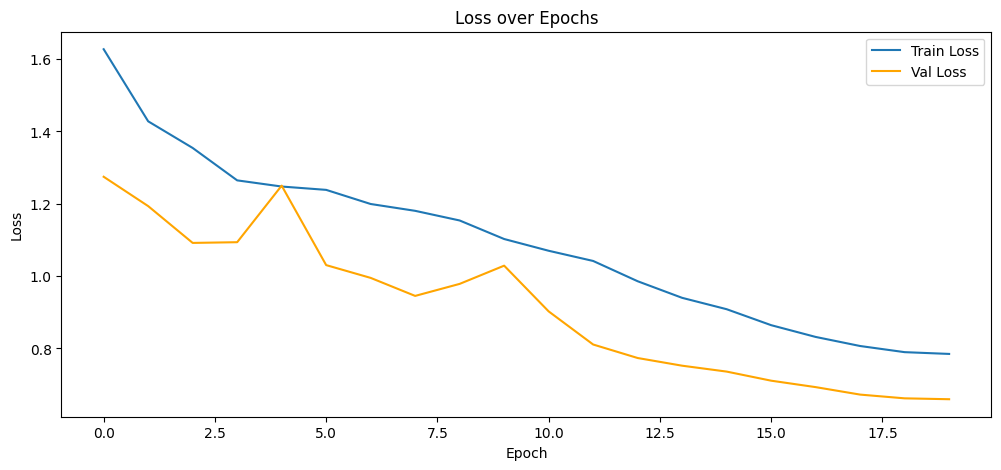

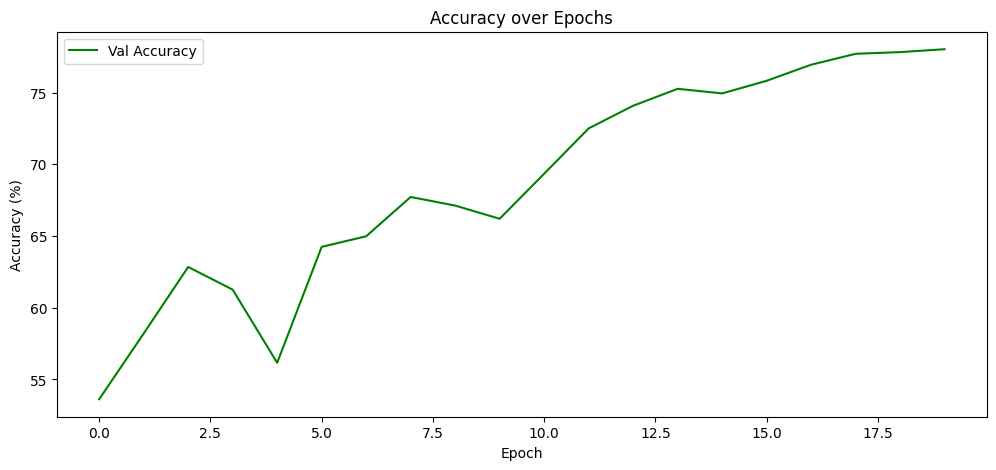

In [6]:

# 1. Plot Loss Curves 
plt.figure(figsize=(12, 5))
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss', color='orange') 
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# 2. Plot Accuracy
plt.figure(figsize=(12, 5))
plt.plot(val_acc, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

### **Analyse model nr 1**

Det är en tydlig nedgång på losskurvorna för både min träning- och valideringsloss. Träning- och valideringslossen fortsätter att sjunka stabilt vilket tyder på att modellen lär sig istället för att memorisera dvs "overfitt". Man kan även se att valderingsloss kurvan ökar upp och sen ner två gånger vilket kan ske när modellen försöker hitta rätt learningrate. Det som är spännande här är att valideringsloss är lägre än träningsloss vilket är resultat av att jag har använt data augmentation, det gör att modellen får svårare bilder under träning men inte under validering.
Fortsatt träning kan dock leda till overfitt dvs att modellen memorerar istället för att lära sig.

Validerings accuracy är strax över 78% och test accuracy är över 77%. 

**Obs. testerna finns i celler längre ner för alla modeller.**

---
## **Model nr 2**

In [7]:
# Define CNN model number 2
class CNN2(nn.Module):
    def __init__(self):
        super(CNN2, self).__init__()
     
        #Feature extraction layers
        self.features = nn.Sequential(
            #Input: [3, 32, 32]
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64), 
            nn.ReLU(),
            #Output: [64, 32, 32]
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            #Output: [64, 32, 32]
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            #Output after maxpool: [64, 16, 16]
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            #Output: [128, 16, 16]
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            #Output: [128, 16, 16]
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            #Output after maxpool: [128, 8, 8]
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            #Output: [256, 8, 8]
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            #Output: [256, 8, 8]
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3)
            #Output after maxpool: [256, 4, 4]
        )
        
        # Classifier layers
        self.classifier = nn.Sequential(
            nn.Flatten(), 
            #Output size: 256*4*4 = 4096
            nn.Linear(in_features=256 * 4 * 4, out_features=512),
            nn.ReLU(),
            #Output size: 512
            nn.Dropout(0.3),
            nn.Linear(in_features=512, out_features=10) 
            #Output size: 10
        )

    def forward(self, x):
        #Input shape: [3, 32, 32]
        x = self.features(x)
        #Shape after features: [256, 4, 4]
        x = self.classifier(x)
        #Final output shape: [10]
        return x



In [8]:
model2 = CNN2()
criterion = nn.CrossEntropyLoss()
optimizer2 = optim.AdamW(model2.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer2, 
    max_lr=0.012, 
    steps_per_epoch=len(train_dataloader), 
    epochs=20, 
    pct_start=0.3, 
    anneal_strategy='cos'
)
print("Training Model 2...")
train_loss2, val_loss2, val_acc2 = train_model(model2, train_dataloader, val_dataloader, criterion, optimizer2, scheduler, epochs=20)

Training Model 2...
Epoch [1/20] - Train Loss: 1.5648, Val Loss: 1.2248, Val Acc: 56.12% - LR: 0.001252
Epoch [2/20] - Train Loss: 1.2894, Val Loss: 1.2107, Val Acc: 57.06% - LR: 0.003361
Epoch [3/20] - Train Loss: 1.1258, Val Loss: 0.9273, Val Acc: 66.78% - LR: 0.006242
Epoch [4/20] - Train Loss: 1.0249, Val Loss: 0.9757, Val Acc: 68.12% - LR: 0.009122
Epoch [5/20] - Train Loss: 0.9827, Val Loss: 0.9815, Val Acc: 67.36% - LR: 0.011230
Epoch [6/20] - Train Loss: 0.9502, Val Loss: 0.8146, Val Acc: 73.22% - LR: 0.012000
Epoch [7/20] - Train Loss: 0.8946, Val Loss: 0.7961, Val Acc: 73.34% - LR: 0.011849
Epoch [8/20] - Train Loss: 0.8503, Val Loss: 0.8587, Val Acc: 73.76% - LR: 0.011405
Epoch [9/20] - Train Loss: 0.8054, Val Loss: 0.8763, Val Acc: 73.02% - LR: 0.010690
Epoch [10/20] - Train Loss: 0.7621, Val Loss: 0.6435, Val Acc: 78.78% - LR: 0.009739
Epoch [11/20] - Train Loss: 0.7101, Val Loss: 0.6486, Val Acc: 78.48% - LR: 0.008602
Epoch [12/20] - Train Loss: 0.6554, Val Loss: 0.5586, 

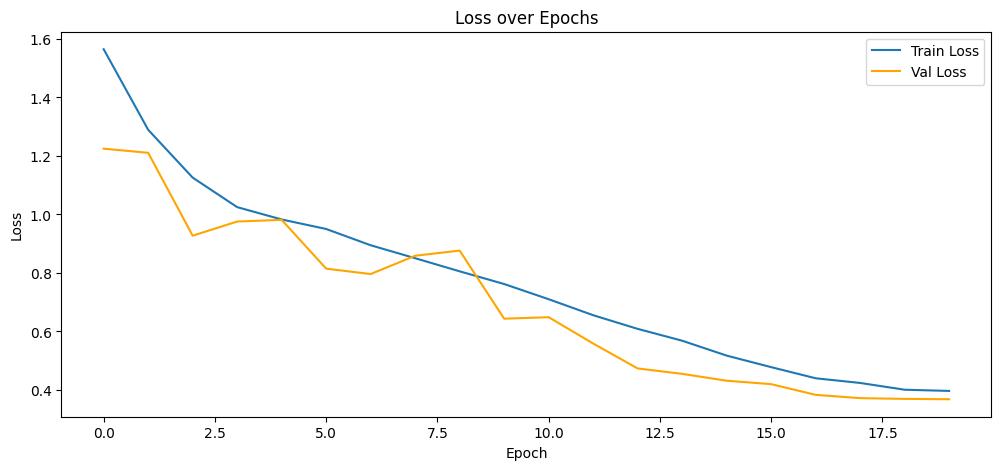

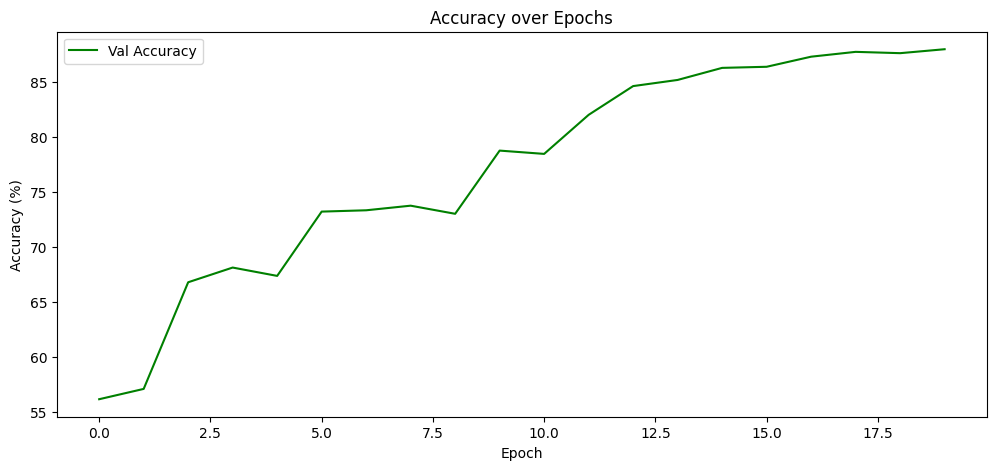

In [9]:

# 1. Plot Loss Curves 
plt.figure(figsize=(12, 5))
plt.plot(train_loss2, label='Train Loss')
plt.plot(val_loss2, label='Val Loss', color='orange') 
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# 2. Plot Accuracy
plt.figure(figsize=(12, 5))
plt.plot(val_acc2, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

### **Analyse model nr 2**

Min andra modell visar att det är en mer komplex ariktektur som kan hitta fler samband och detaljer i bilderna vilket man kan se på den snabbare nedgången i kurvorna. Även här kan man se att valideringslossen är lägre än träningslossen pga data augmentation och droupout, men kurvorna ligger tätare ihop och det tyder på att modellen är bättre på att generalisera. Ingen tydan på overfitting här och man skulle kunna träna modellen ytterligare. Denna modell är betydligt bättre än första modellen.

Validerings accuracy är strax över 88% och test accuracy är över 87%. 


---
## Model nr 3

In [10]:
# Define CNN model number 3
class CNN3(nn.Module):
    def __init__(self):
        super(CNN3, self).__init__()
        
        # FEATURE EXTRACTION 
        self.features = nn.Sequential(
            #Input: [3, 32, 32]
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64), 
            nn.ReLU(),
            #Output: [64, 32, 32]
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding='same'),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            #Output: [64, 32, 32]
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            #Output after maxpool: [64, 16, 16]
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            #Output: [128, 16, 16]
            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same'),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            #Output: [128, 16, 16]
            nn.MaxPool2d(2, 2), 
            nn.Dropout(0.3),
            #Output after maxpool: [128, 8, 8]
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            #Output: [256, 8, 8]
            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding='same'),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            #Output: [256, 8, 8]
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.3),
            #Output after maxpool: [256, 4, 4]

            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, padding='same'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            #Output: [512, 4, 4]
            nn.Conv2d(in_channels=512, out_channels=512, kernel_size=3, padding='same'),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            #Output: [512, 4, 4]
            nn.AdaptiveAvgPool2d(1) 
            #Output: [512, 1, 1]
        )
        
        # CLASSIFIER LAYERS
        self.classifier = nn.Sequential(
            nn.Flatten(),
            #Output size: 512*1*1 = 512
            nn.Linear(in_features=512, out_features= 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            #Output size: 512

            nn.Linear(in_features=512, out_features=10) 
            #Output size: 10
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



In [11]:
model3 = CNN3()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 
optimizer3 = optim.AdamW(model3.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer3, 
    max_lr=0.005, 
    steps_per_epoch=len(train_dataloader), 
    epochs=30, 
    pct_start=0.3, 
    anneal_strategy='cos'
)
print("Training Model 3...")
train_loss3, val_loss3, val_acc3 = train_model(model3, train_dataloader, val_dataloader, criterion, optimizer3, scheduler, epochs=30)

Training Model 3...
Epoch [1/30] - Train Loss: 1.6757, Val Loss: 1.7864, Val Acc: 48.92% - LR: 0.000345
Epoch [2/30] - Train Loss: 1.3786, Val Loss: 1.3366, Val Acc: 63.28% - LR: 0.000762
Epoch [3/30] - Train Loss: 1.2660, Val Loss: 1.3428, Val Acc: 63.88% - LR: 0.001400
Epoch [4/30] - Train Loss: 1.1969, Val Loss: 1.1693, Val Acc: 73.42% - LR: 0.002184
Epoch [5/30] - Train Loss: 1.1422, Val Loss: 1.0751, Val Acc: 75.94% - LR: 0.003017
Epoch [6/30] - Train Loss: 1.1007, Val Loss: 1.1430, Val Acc: 73.70% - LR: 0.003801
Epoch [7/30] - Train Loss: 1.0498, Val Loss: 1.0249, Val Acc: 78.10% - LR: 0.004439
Epoch [8/30] - Train Loss: 1.0172, Val Loss: 0.9912, Val Acc: 80.04% - LR: 0.004856
Epoch [9/30] - Train Loss: 0.9866, Val Loss: 0.9702, Val Acc: 80.74% - LR: 0.005000
Epoch [10/30] - Train Loss: 0.9587, Val Loss: 0.9067, Val Acc: 83.34% - LR: 0.004972
Epoch [11/30] - Train Loss: 0.9278, Val Loss: 0.9103, Val Acc: 83.56% - LR: 0.004889
Epoch [12/30] - Train Loss: 0.8994, Val Loss: 0.8474, 

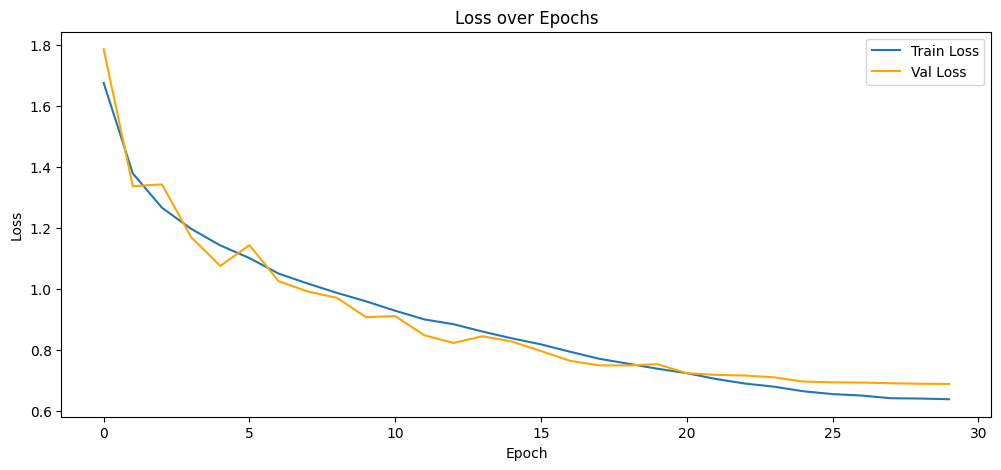

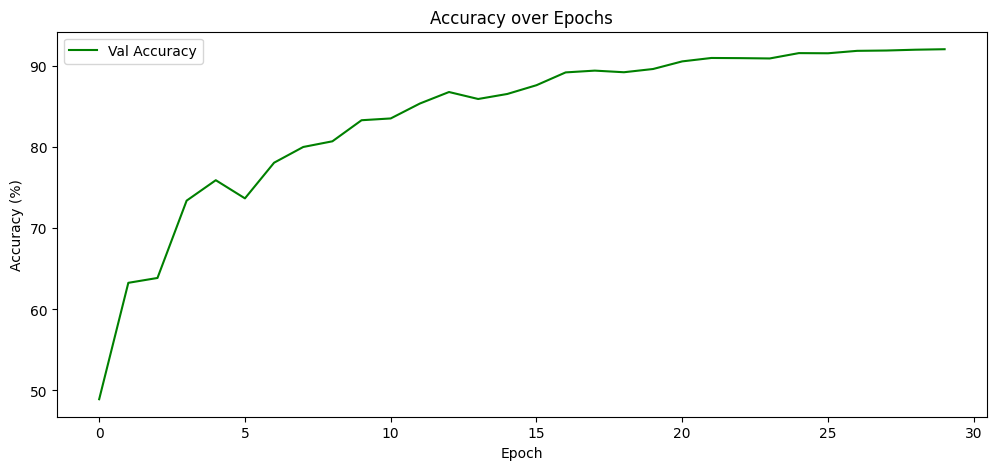

In [12]:

# 1. Plot Loss Curves 
plt.figure(figsize=(12, 5))
plt.plot(train_loss3, label='Train Loss')
plt.plot(val_loss3, label='Val Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()

# 2. Plot Accuracy
plt.figure(figsize=(12, 5))
plt.plot(val_acc3, label='Val Accuracy', color='green')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

### **Analyse model nr 3**

Man kan se på loss-kurvorna att modellen är ännu mer komplex med fler lager och filter då kurvorna sjunker väldigt jämnt och snabbare. Valideringskurvan är mindre spretig på slutet och det är resultatet av att jag använde ApaptiveAvgPool2d() som hjälper modellen att regualrisera. Det är inte ett stort gap mellan kurvorna här heller och visar återigen att modellen lär sig och generliserar bra, skillnaden är på denna och förra modell är att kurvorna håller sig tät ihop under alla epoker. Det finns en risk för overfit om man fortsätter träna. 

Validerings accuracy är strax över 92% och test accuracy är över 91%. 


---
**Evaluate on the test-set**

In [13]:
def evaluate_model(model, test_loader):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    model.eval() 
    
    correct = 0
    total = 0
    
    with torch.no_grad(): 
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f}%')
    return accuracy

In [14]:

print("Evaluating Model 1 on test set...")
test_acc1 = evaluate_model(model1, test_dataloader)

print("Evaluating Model 2 on test set...")
test_acc2 = evaluate_model(model2, test_dataloader)

print("Evaluating Model 3 on test set...")
test_acc3 = evaluate_model(model3, test_dataloader)

Evaluating Model 1 on test set...
Test Accuracy: 77.29%
Evaluating Model 2 on test set...
Test Accuracy: 87.34%
Evaluating Model 3 on test set...
Test Accuracy: 91.60%


In [15]:
test_accuracies = []

print("Evaluating all models on test set...")
test_accuracies.append(evaluate_model(model1, test_dataloader))
test_accuracies.append(evaluate_model(model2, test_dataloader))
test_accuracies.append(evaluate_model(model3, test_dataloader))

Evaluating all models on test set...
Test Accuracy: 77.29%
Test Accuracy: 87.34%
Test Accuracy: 91.60%


---
## **Training Methods & Techniques Explained**

**Data Augmentation**
- `RandomHorizontalFlip()`: Randomly flips images horizontally, increases dataset diversity without more data
- `RandomCrop(32, padding=4)`: Crops images with padding, helps model learn position-invariance
- `Normalize()`: Standardizes images using CIFAR-10 mean/std, stabilizes training
- Applied only to training data, not validation/test (prevents data leakage)

**Batch Normalization (`BatchNorm2d`)**
- Normalizes activations within each batch to zero mean and unit variance
- Reduces internal covariate shift, allowing higher learning rates
- Acts as slight regularizer, reduces dependence on weight initialization
- Speeds up training and stabilizes convergence

**Dropout**
- Randomly deactivates neurons during training (probability 0.3-0.4)
- Prevents co-adaptation of neurons, reduces overfitting
- Forced to learn redundant representations
- Only applied during training, disabled during evaluation

**AdamW Optimizer**
- Adaptive learning rate optimizer with decoupled weight decay (L2 regularization)
- Better than standard Adam for modern deep learning
- `weight_decay=1e-4`: Applies L2 regularization to prevent overfitting
- Typically outperforms SGD on complex tasks

**OneCycleLR Scheduler**
- Learning rate starts low, increases to max, then decreases
- `max_lr`: Peak learning rate during training
- `pct_start=0.3`: 30% of epochs spent increasing LR, 70% decreasing
- `anneal_strategy='cos'`: Uses cosine annealing for smooth LR decay
- Improves convergence and prevents overfitting at training end

**Label Smoothing (`label_smoothing=0.1` in Model 3)**
- Instead of one-hot encoding (1,0,0,...), uses smooth targets (0.9, 0.033, 0.033,...)
- Prevents overconfidence and overspecialization
- Reduces overfitting by regularizing the loss function
- Typically improves generalization on test data

**CrossEntropyLoss**
- Standard loss for multi-class classification
- Combines softmax activation with negative log-likelihood
- Automatically handles probability normalization
- Provides stable gradients during backpropagation


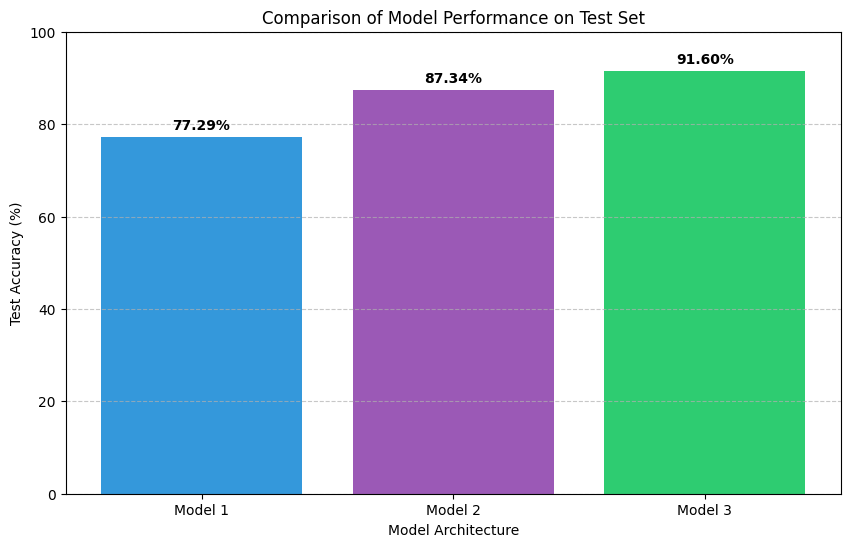

In [16]:
def plot_model_comparison(test_accs):
    models = ['Model 1', 'Model 2', 'Model 3']
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(models, test_accs, color=['#3498db', '#9b59b6', '#2ecc71'])
    
    plt.xlabel('Model Architecture')
    plt.ylabel('Test Accuracy (%)')
    plt.title('Comparison of Model Performance on Test Set')
    plt.ylim(0, 100) 
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_model_comparison(test_accuracies)

---
**Error analysis**

Generating confusion matrix data...


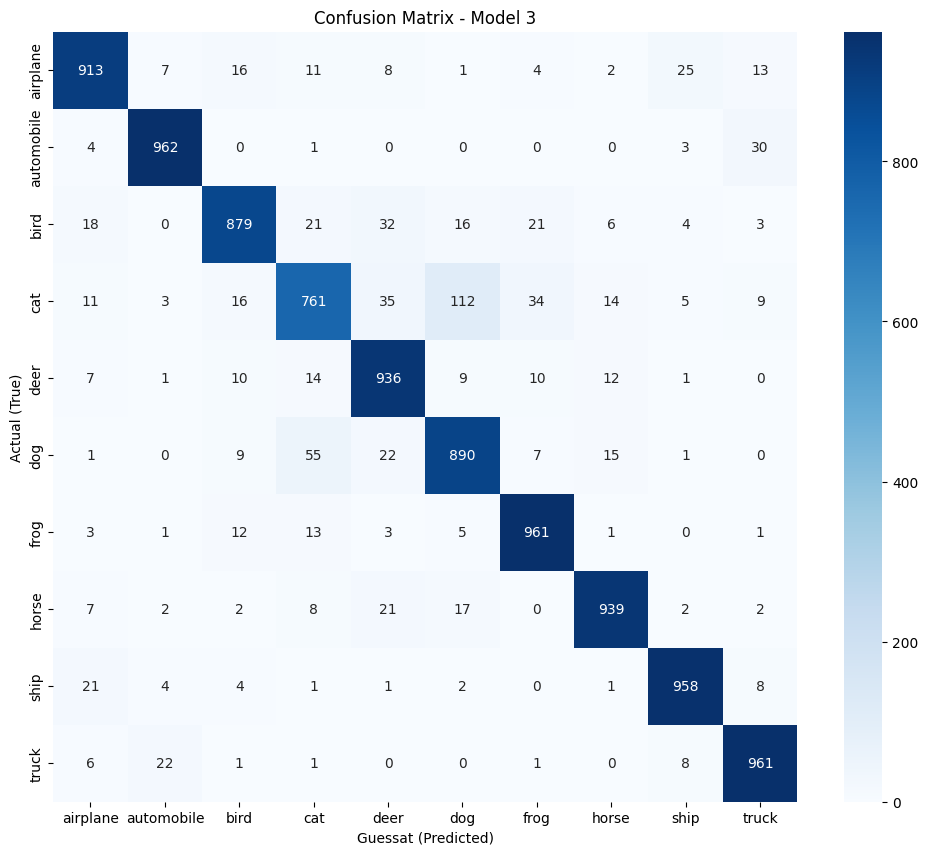

In [17]:
def plot_confusion_matrix(model, test_loader, class_names):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    model.eval()
    all_preds = []
    all_labels = []
    
    print("Generating confusion matrix data...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Guessat (Predicted)')
    plt.ylabel('Actual (True)')
    plt.title('Confusion Matrix - Model 3')
    plt.show()

plot_confusion_matrix(model3, test_dataloader, test_base.classes) # test_base.classes contains the class names

Searching for misclassified images...


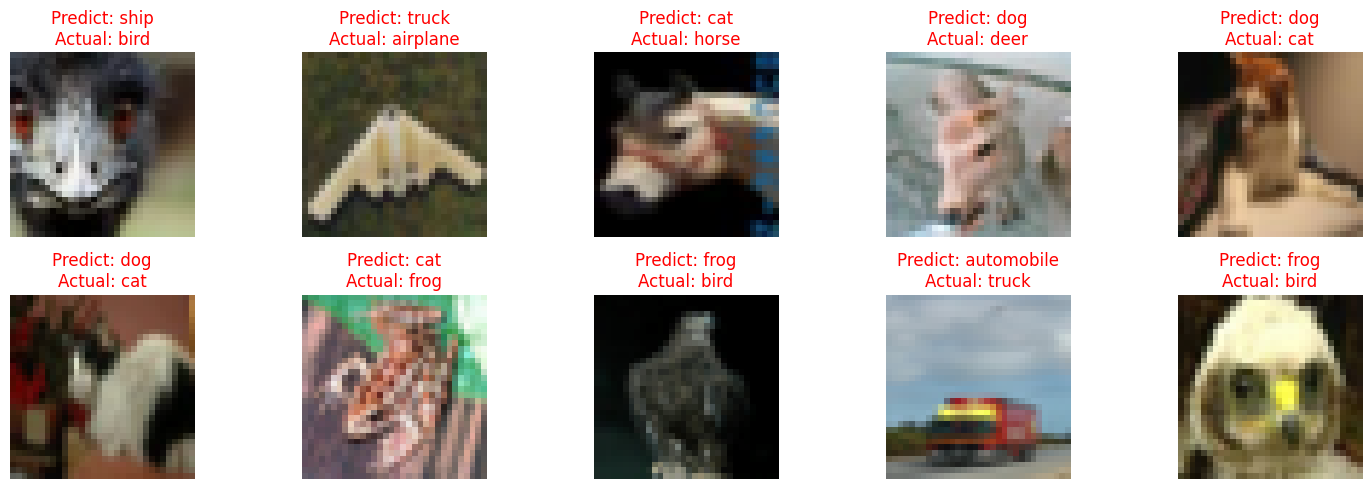

In [18]:
def plot_misclassified(model, test_loader, class_names, num_images=10):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    misclassified_images = []
    actual_labels = []
    predicted_labels = []
    
    print("Searching for misclassified images...")
    with torch.no_grad():
        for images, labels in test_loader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            _, preds = torch.max(outputs, 1)
            
            #Find where predictions do not match the actual labels
            mask = (preds != labels.to(device))
            
            if mask.any():
                # Save misclassified images and their labels
                misclassified_images.extend(images[mask.cpu()])
                actual_labels.extend(labels[mask.cpu()].numpy())
                predicted_labels.extend(preds[mask.cpu()].cpu().numpy())
                
            if len(misclassified_images) >= num_images:
                break

    # Plot predicted vs actual for misclassified images
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(2, 5, i + 1)
        
        # Denormalize for correct display using same mean/std as in the transform
        img = misclassified_images[i].numpy().transpose((1, 2, 0))
        mean = np.array([0.4914, 0.4822, 0.4465])
        std = np.array([0.2470, 0.2435, 0.2616])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        plt.imshow(img)
        plt.title(f"Predict: {class_names[predicted_labels[i]]}\nActual: {class_names[actual_labels[i]]}", 
                  color='red' if predicted_labels[i] != actual_labels[i] else 'green')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

plot_misclassified(model3, test_dataloader, test_base.classes)

Analyzing confident errors...


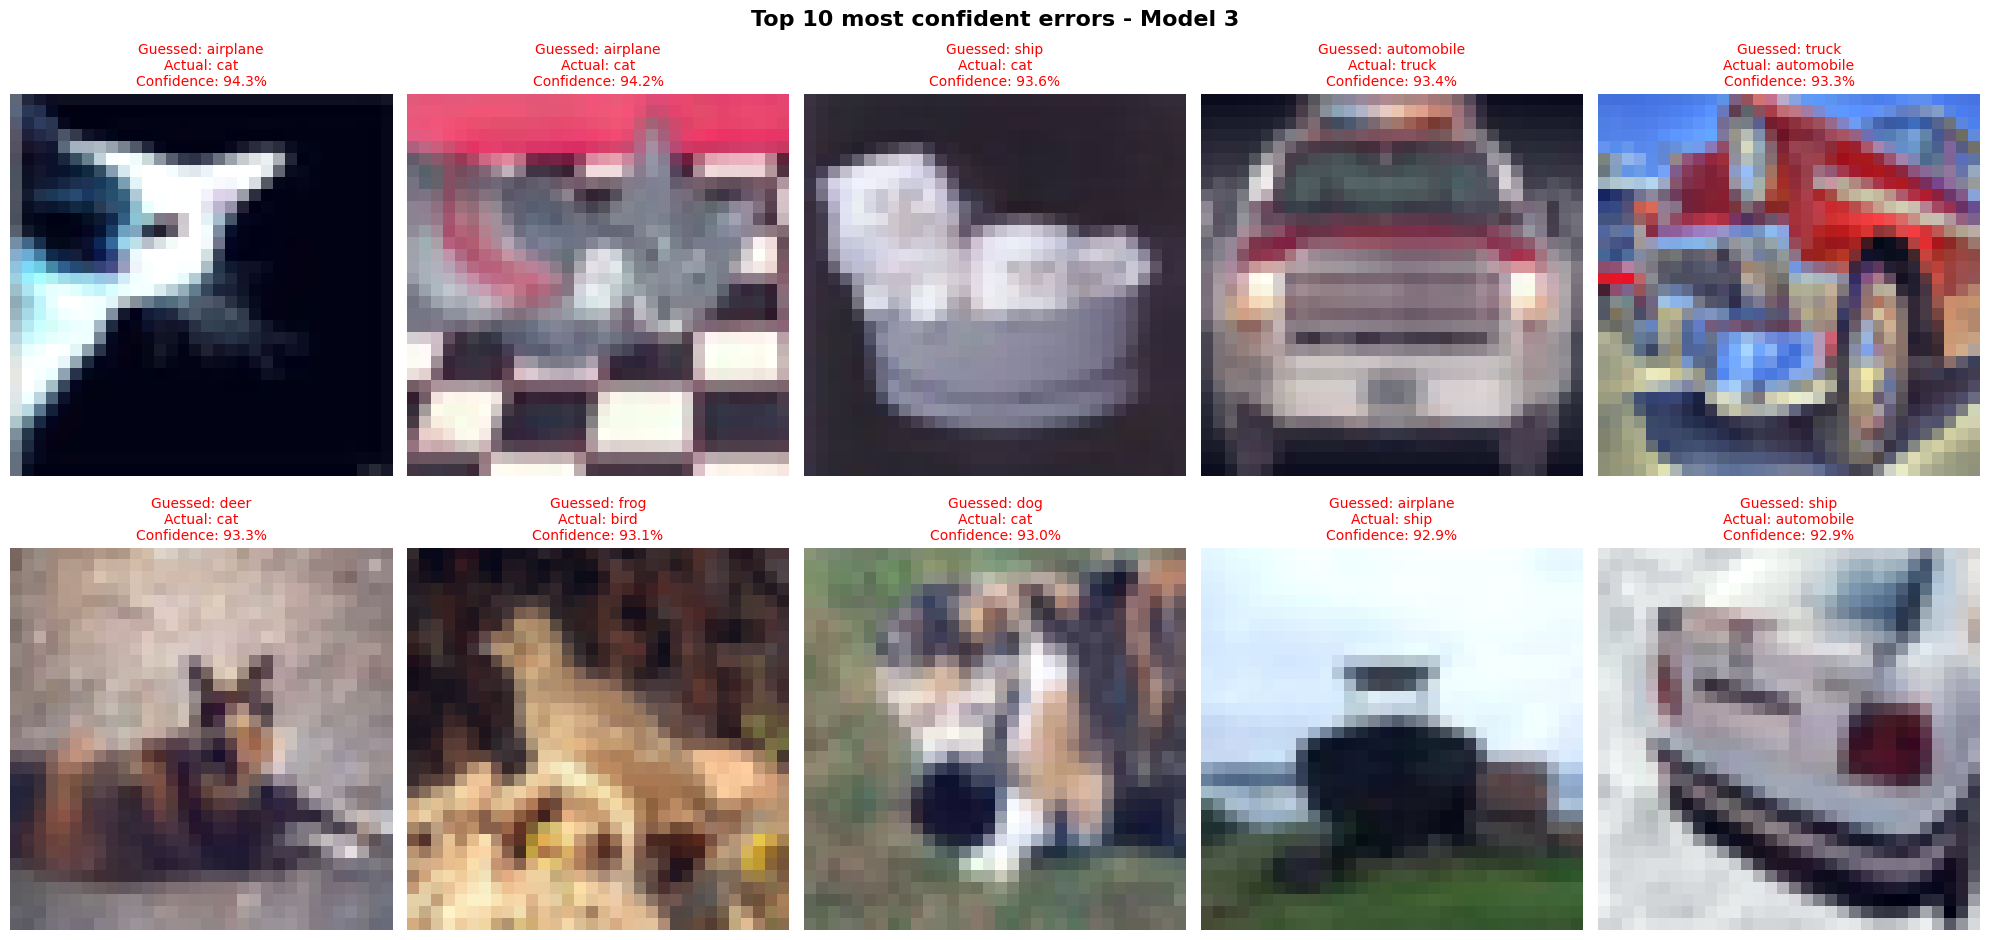

In [19]:
def plot_confident_errors(model, test_loader, class_names, num_images=10):
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    model.to(device)
    model.eval()
    
    all_errors = []
    
    print("Analyzing confident errors...")
    with torch.no_grad():
        for images, labels in test_loader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            
            # transform outputs to probabilities (0.0 - 1.0)
            probabilities = torch.softmax(outputs, dim=1)
            conf, preds = torch.max(probabilities, 1)
            
            # Find where predictions do not match the actual labels
            mask = (preds != labels.to(device))
            
            # Save info for misclassified images
            if mask.any():
                batch_errors = zip(
                    images[mask.cpu()], 
                    labels[mask.cpu()].numpy(), 
                    preds[mask.cpu()].cpu().numpy(), 
                    conf[mask.cpu()].cpu().numpy()
                )
                all_errors.extend(list(batch_errors))

    # Sort errors based on confidence (highest first)
    all_errors.sort(key=lambda x: x[3], reverse=True)

    # Plot the most confident errors
    plt.figure(figsize=(20, 10))
    for i in range(min(num_images, len(all_errors))):
        img_tensor, actual, pred, confidence = all_errors[i]
        
        plt.subplot(2, 5, i + 1)
        
        # Denormalize for correct display 
        img = img_tensor.numpy().transpose((1, 2, 0))
        img = np.clip(img * 0.25 + 0.5, 0, 1) 
        
        plt.imshow(img)
        plt.title(f"Guessed: {class_names[pred]}\n"
                  f"Actual: {class_names[actual]}\n"
                  f"Confidence: {confidence*100:.1f}%", 
                  color='red', fontsize=10)
        plt.axis('off')
    
    plt.suptitle(f"Top {num_images} most confident errors - Model 3", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Kör analysen
plot_confident_errors(model3, test_dataloader, test_base.classes, num_images=10)

In [20]:
from sklearn.metrics import classification_report

device = torch.device('mps' if torch.mps.is_available() else 'cpu')
model3.to(device)

def show_classification_report(model, test_loader, class_names):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            outputs = model(imgs.to(device))
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            
    print(classification_report(y_true, y_pred, target_names=class_names))

show_classification_report(model3, test_dataloader, test_base.classes)

              precision    recall  f1-score   support

    airplane       0.92      0.91      0.92      1000
  automobile       0.96      0.96      0.96      1000
        bird       0.93      0.88      0.90      1000
         cat       0.86      0.76      0.81      1000
        deer       0.88      0.94      0.91      1000
         dog       0.85      0.89      0.87      1000
        frog       0.93      0.96      0.94      1000
       horse       0.95      0.94      0.94      1000
        ship       0.95      0.96      0.95      1000
       truck       0.94      0.96      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



---
**Pretrained model**⭐️

In [21]:
import torchvision.models as models
import copy

model = models.efficientnet_b3(weights='IMAGENET1K_V1')
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 10)


In [24]:
model = models.efficientnet_b3(weights='IMAGENET1K_V1')
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 10)

print(f"Använder modell: {model.__class__.__name__}")

print("\n" + "="*60)
print("FAS 1: Warm-up - Tränar bara classifier")
print("="*60)


Använder modell: EfficientNet

FAS 1: Warm-up - Tränar bara classifier


In [ ]:
# 2. Initiera den nya modellen
pretrained_model = get_pretrained_model()
pretrained_model.to(device) # Se till att den flyttas till GPU/MPS

# 3. Definiera Optimizer för ENBART de parametrar som inte är frysta
# Detta är säkrare för att behålla de förtränade vikterna
trainable_params = [p for p in pretrained_model.parameters() if p.requires_grad]
optimizer_pretrained = torch.optim.AdamW(trainable_params, lr=1e-3) # Högre LR för huvudet

# 4. Ny scheduler för 10 epoker
epochs_pretrained = 10
scheduler_pretrained = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_pretrained, 
    max_lr=1e-3, 
    steps_per_epoch=len(train_dataloader), 
    epochs=epochs_pretrained
)

# 5. Kör träningen
history_pretrained = train_model(
    pretrained_model, 
    train_dataloader, 
    val_dataloader, 
    criterion, 
    optimizer_pretrained,  
    scheduler_pretrained, 
    epochs=epochs_pretrained
)


Epoch [1/10] - Train Loss: 1.5221, Val Loss: 1.1374, Val Acc: 74.58% - LR: 0.000280
Epoch [2/10] - Train Loss: 1.1864, Val Loss: 1.0888, Val Acc: 76.50% - LR: 0.000760
Epoch [3/10] - Train Loss: 1.1594, Val Loss: 1.0954, Val Acc: 75.62% - LR: 0.001000
Epoch [4/10] - Train Loss: 1.1379, Val Loss: 1.0548, Val Acc: 77.92% - LR: 0.000950
Epoch [5/10] - Train Loss: 1.1193, Val Loss: 1.0544, Val Acc: 77.48% - LR: 0.000811
Epoch [6/10] - Train Loss: 1.0909, Val Loss: 1.0278, Val Acc: 79.38% - LR: 0.000611
Epoch [7/10] - Train Loss: 1.0717, Val Loss: 1.0175, Val Acc: 79.42% - LR: 0.000388
Epoch [8/10] - Train Loss: 1.0532, Val Loss: 1.0058, Val Acc: 80.00% - LR: 0.000188
Epoch [9/10] - Train Loss: 1.0334, Val Loss: 0.9942, Val Acc: 80.38% - LR: 0.000049
Epoch [10/10] - Train Loss: 1.0257, Val Loss: 0.9965, Val Acc: 80.48% - LR: 0.000000
Training completed!


---
**Just having fun seeing diffrent layers**

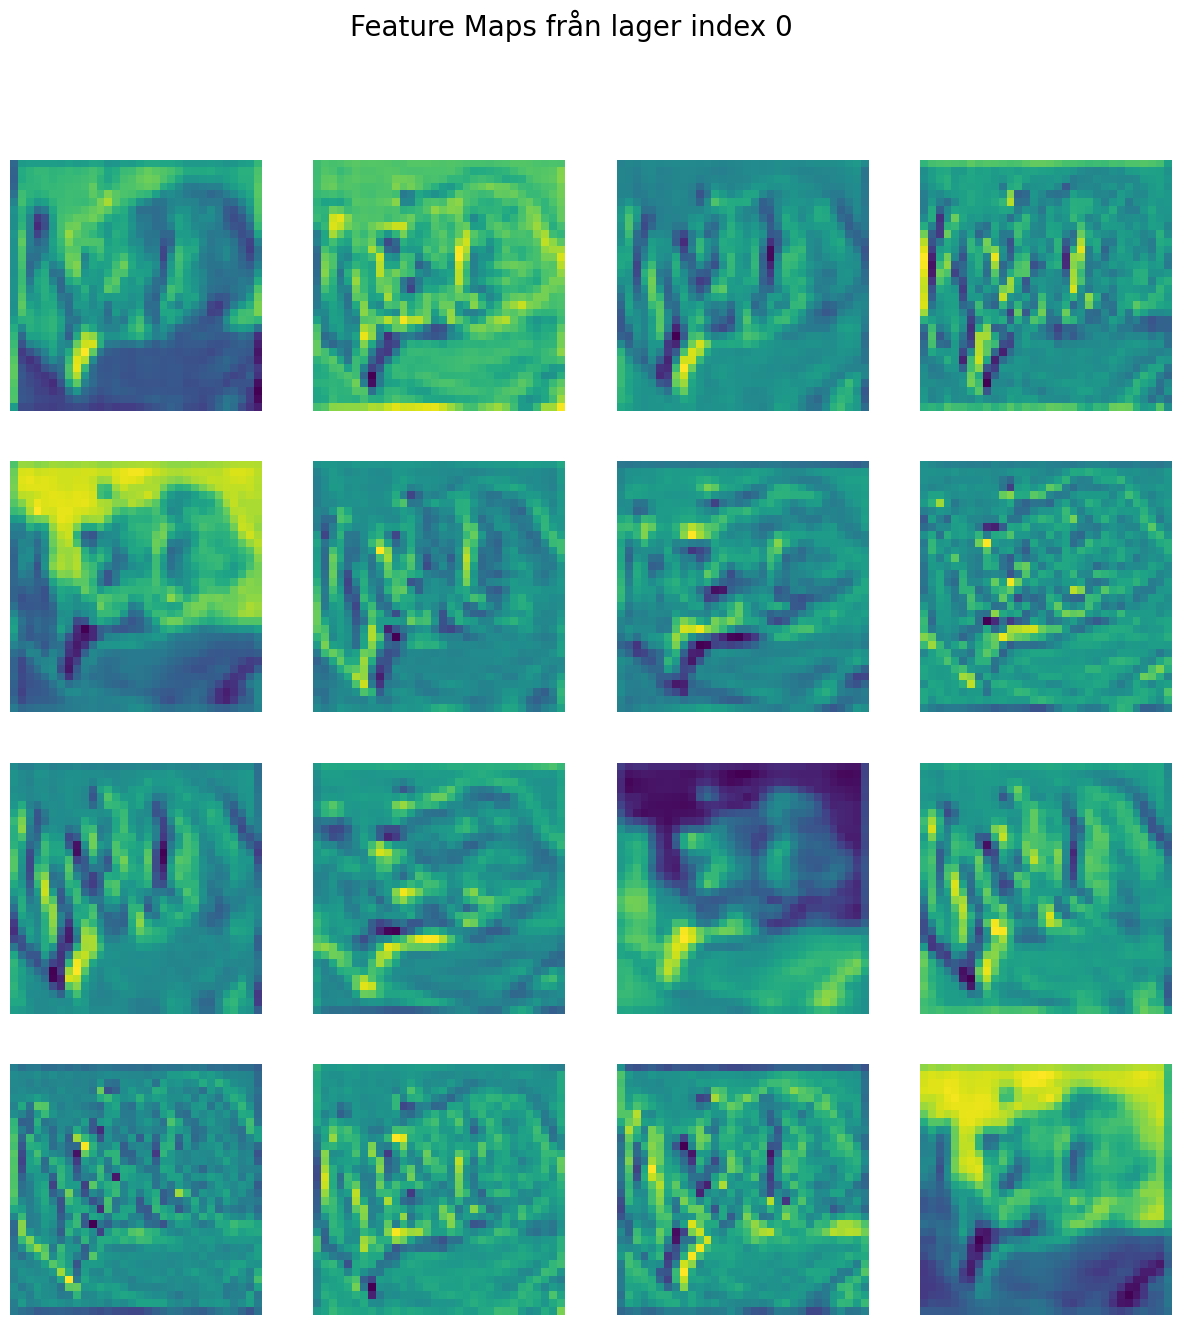

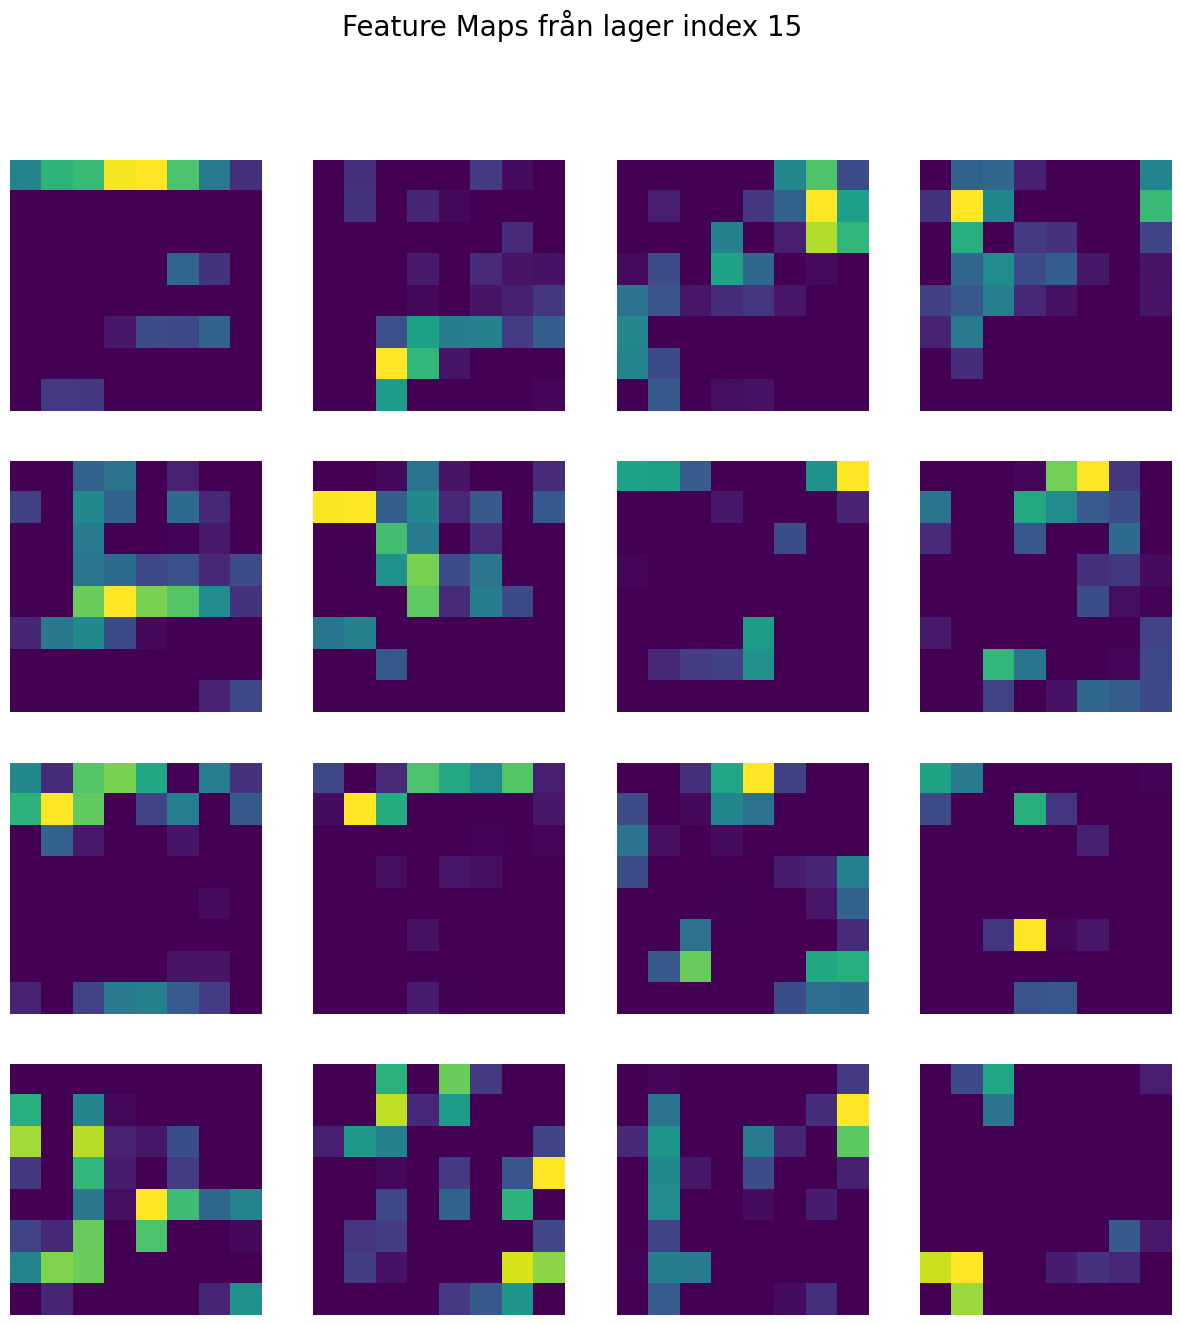

In [ ]:
def plot_deeper_feature_maps(model, image, block_idx):
    model.eval()
    device = torch.device('mps' if torch.mps.is_available() else 'cpu')
    
    # Create a sub-model up to the specified block index
    layers = list(model.features.children())[:block_idx+1]
    feature_extractor = nn.Sequential(*layers).to(device)
    
    with torch.no_grad():
        f_maps = feature_extractor(image.to(device).unsqueeze(0))
    
    # Plot the first 16 feature maps 
    plt.figure(figsize=(15, 15))
    channels = min(f_maps.shape[1], 16) 
    for i in range(channels):
        plt.subplot(4, 4, i+1)
        # Use 'viridis' colormap for better visibility
        plt.imshow(f_maps[0, i].cpu(), cmap='viridis') 
        plt.axis('off')
    
    plt.suptitle(f"Feature Maps från lager index {block_idx}", fontsize=20)
    plt.show()

# Test to view feature maps from the first convolutional layer
plot_deeper_feature_maps(model3, sample_img, 0)

# Test to view feature maps from a deeper layer
plot_deeper_feature_maps(model3, sample_img, 15)